In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vplanbb/spotify11/dataset.csv


In [7]:
import pandas as pd

vp = pd.read_csv('/kaggle/input/datasets/vplanbb/spotify11/dataset.csv')

In [8]:
vp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [9]:
# Смотрим количество уникальных значений по каждому столбцу
for col in vp.columns:
    print(f"\nКолонка: {col}")
    print("Тип:", vp[col].dtype)
    unique_vals = vp[col].unique()
    print("Количество уникальных значений:", len(unique_vals))
    print("Примеры уникальных значений:", unique_vals[:10])


Колонка: Unnamed: 0
Тип: int64
Количество уникальных значений: 114000
Примеры уникальных значений: [0 1 2 3 4 5 6 7 8 9]

Колонка: track_id
Тип: object
Количество уникальных значений: 89741
Примеры уникальных значений: ['5SuOikwiRyPMVoIQDJUgSV' '4qPNDBW1i3p13qLCt0Ki3A'
 '1iJBSr7s7jYXzM8EGcbK5b' '6lfxq3CG4xtTiEg7opyCyx'
 '5vjLSffimiIP26QG5WcN2K' '01MVOl9KtVTNfFiBU9I7dc'
 '6Vc5wAMmXdKIAM7WUoEb7N' '1EzrEOXmMH3G43AXT1y7pA'
 '0IktbUcnAGrvD03AWnz3Q8' '7k9GuJYLp2AzqokyEdwEw2']

Колонка: artists
Тип: object
Количество уникальных значений: 31438
Примеры уникальных значений: ['Gen Hoshino' 'Ben Woodward' 'Ingrid Michaelson;ZAYN' 'Kina Grannis'
 'Chord Overstreet' 'Tyrone Wells' 'A Great Big World;Christina Aguilera'
 'Jason Mraz' 'Jason Mraz;Colbie Caillat' 'Ross Copperman']

Колонка: album_name
Тип: object
Количество уникальных значений: 46590
Примеры уникальных значений: ['Comedy' 'Ghost (Acoustic)' 'To Begin Again'
 'Crazy Rich Asians (Original Motion Picture Soundtrack)' 'Hold On'
 'Days I 

In [10]:
#Описание датасета Spotify Tracks c расшифровкой всех столбцов

#Unnamed: 0
#Техническая колонка-индекс.

#track_id
#Уникальный идентификатор трека в Spotify.

#artists
#Исполнитель трека.  

#album_name
#Название альбома.  
#Тоже имеет высокую уникальность.

#track_name
#Название композиции.  
#Очень высокая уникальность → не используется как признак напрямую.

#popularity
#Популярность трека по версии Spotify (0–100).  (таргет)

#duration_ms
#Длительность трека в миллисекундах.

#explicit
#Признак наличия ненормативной лексики:
#True — трек содержит мат / 18+  
#False — «чистый» трек  

Бинарный признак.

#danceability
#Танцевальность трека (0–1).  
#1 - максимально танцевальный.

#energy
#Энергичность трека (0–1).

#key
#Музыкальная тональность (0–11).  
#Spotify кодирует ноты: C=0 … B=11.

#loudness
#Средняя громкость трека в децибелах.

#mode
#Тип тональности:
#1 — мажор
#0 — минор

#speechiness
#Количество разговорных элементов в треке (0–1).

#acousticness
#Оценка «акустичности» трека (0–1).

#instrumentalness
#Вероятность того, что трек инструментальный (0–1).

#liveness
#Показатель «живого» исполнения (0–1).

#valence
#Эмоциональная окраска (0–1):  
#0 → грустный трек  
#1 → позитивный трек

#tempo
#Темп трека в BPM (ударов в минуту).

#time_signature
#Музыкальный размер трека.  
#В датасете встречаются значения:
#4 — стандартный размер 
#3 — трёхдольный размер  
#1 — редкий размер  
#5 — сложный размер  
#0 — ошибка/отсутствие данных  

#track_genre
#Основной жанр трека (114 категорий).


SyntaxError: invalid syntax (3528341990.py, line 31)

In [11]:
# Смотрим, какие значения popularity встречаются чаще всего
vp['popularity'].value_counts().head(10)

popularity
0     16020
22     2354
21     2344
44     2288
1      2140
23     2117
20     2110
43     2073
45     2004
41     1996
Name: count, dtype: int64

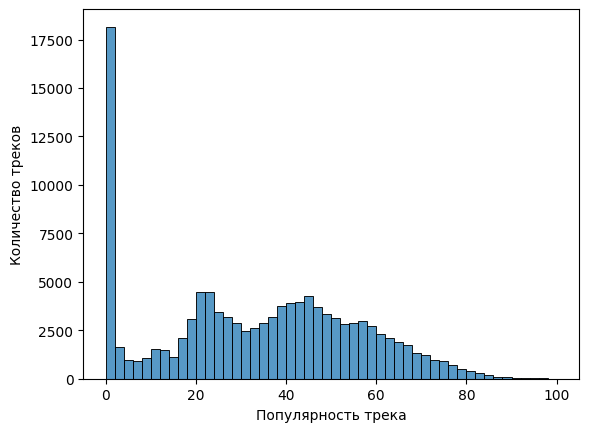

In [12]:
# Подключаю библиотеки для визуализации
import seaborn as sns
import matplotlib.pyplot as plt

# На этом шаге я смотрю распределение целевой переменной popularity.

sns.histplot(vp['popularity'], bins=50)

plt.xlabel('Популярность трека')
plt.ylabel('Количество треков')

plt.show()

In [ ]:
# Удаление нулевых значений популярности

#При анализе данных я заметил, что в столбце `popularity` примерно 14% записей имеют значение 0.  
#После изучения документации Spotify стало понятно, что такое значение обычно означает отсутствие данных, а не реальный рейтинг трека.  

#Если оставить нули в датасете, модель регрессии будет смещаться в сторону предсказания низких значений. Это ухудшит результаты регрессии и сделает модель неэффективной.

#Чтобы избежать проблем на следующих этапах, я удаляю строки, где популярность равна нулю.  
#Это действие улучшит распределение целевого признака и качество последующих моделей.


In [13]:
# Удаляю треки, у которых популярность равна нулю
vp = vp[vp['popularity'] > 0].reset_index(drop=True)

# Проверяю, что нулевых значений больше нет
vp['popularity'].value_counts().head()

popularity
22    2354
21    2344
44    2288
1     2140
23    2117
Name: count, dtype: int64

In [14]:
# Удаляю технический индексный столбец
if 'Unnamed: 0' in vp.columns:
    vp = vp.drop(columns=['Unnamed: 0'])

vp.head(3)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [15]:
# Проверка пропусков

# Перед обучением моделей мне важно понять, есть ли пропущенные значения в данных.
# Пропуски могут приводить к ошибкам при обучении и снижать качество моделей.

# Сейчас я считаю количество пропусков по каждому столбцу, чтобы решить:
# какие значения можно заполнить,
# а какие строки (если их мало) можно удалить.

In [16]:
# Считаю пропуски по каждому столбцу
missing = vp.isnull().sum().sort_values(ascending=False)
missing

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Корреляции числовых признаков с популярностью (Spearman):
instrumentalness   -0.170
speechiness        -0.103
loudness            0.067
energy             -0.066
danceability        0.054
acousticness        0.047
liveness           -0.043
duration_ms        -0.027
tempo              -0.018
valence            -0.014
Name: popularity, dtype: float64


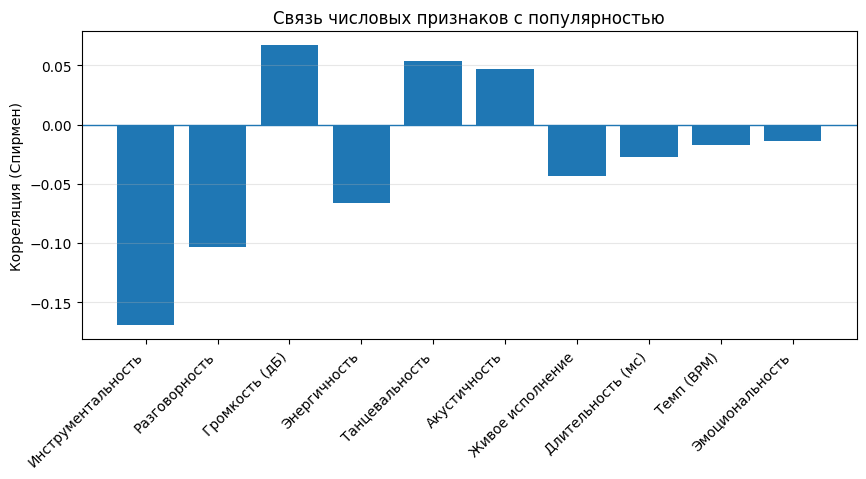

In [17]:
# На этом шаге я хочу понять, какие числовые признаки сильнее всего связаны
# с популярностью трека. Я строю столбчатую диаграмму корреляций,
# чтобы наглядно увидеть, какие признаки влияют сильнее.
# Использую корреляцию Спирмена, так как зависимости могут быть нелинейными.

import matplotlib.pyplot as plt

# Русские названия признаков (для подписей на графике)
ru_names = {
    'duration_ms': 'Длительность (мс)',
    'danceability': 'Танцевальность',
    'energy': 'Энергичность',
    'loudness': 'Громкость (дБ)',
    'speechiness': 'Разговорность',
    'acousticness': 'Акустичность',
    'instrumentalness': 'Инструментальность',
    'liveness': 'Живое исполнение',
    'valence': 'Эмоциональность',
    'tempo': 'Темп (BPM)'
}

num_cols = list(ru_names.keys())

# Считаю корреляции с popularity
corr_with_popularity = (
    vp[num_cols + ['popularity']]
    .corr(method='spearman')['popularity']
    .drop('popularity')
)

# Сортирую по модулю корреляции (чтобы самые сильные были первыми)
corr_sorted = corr_with_popularity.reindex(
    corr_with_popularity.abs().sort_values(ascending=False).index
)

print("Корреляции числовых признаков с популярностью (Spearman):")
print(corr_sorted.round(3))

# Перевожу названия в русские для оси X
x_labels = [ru_names[c] for c in corr_sorted.index]

# Строю столбчатую диаграмму
plt.figure(figsize=(10,4))
plt.bar(x_labels, corr_sorted.values)
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Корреляция (Спирмен)")
plt.title("Связь числовых признаков с популярностью")
plt.grid(axis='y', alpha=0.3)
plt.show()

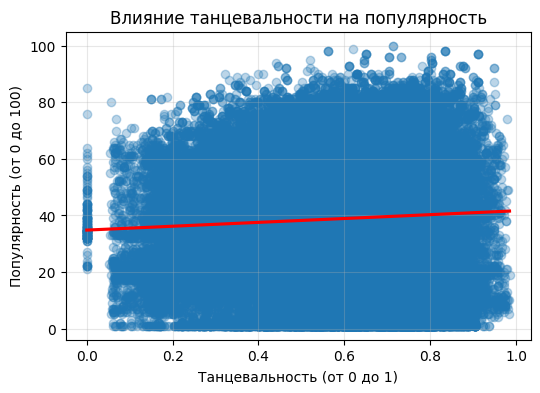

Корреляция Спирмена между танцевальностью и популярностью: 0.054
Гипотеза не подтверждена: явной статистической зависимости не обнаружено.
Танцевальность трека сама по себе не является сильным фактором его популярности.


In [18]:
# Гипотеза 1: чем выше танцевальность трека, тем выше его популярность.
# Для проверки я использую точечную диаграмму с линией тренда, чтобы увидеть общее направление зависимости.

# Импортирую библиотеки для визуализации:
import seaborn as sns
import matplotlib.pyplot as plt

# Создаю область для рисунка размером 6x4 дюймов.
plt.figure(figsize=(6,4))

sns.regplot(
    x=vp['danceability'],
    y=vp['popularity'],
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)

plt.xlabel("Танцевальность (от 0 до 1)")
plt.ylabel("Популярность (от 0 до 100)")
plt.title("Влияние танцевальности на популярность")
plt.grid(alpha=0.3) 
plt.show() 

# Визуально по графику зависимость слабая. Чтобы сделать точный вывод, считаю корреляцию.
# Корреляция Спирмена — это число от -1 до 1, которое измеряет силу и направление статистической связи.
# Она лучше подходит для данных, которые могут быть нелинейными или иметь выбросы.

corr_dance = vp[['danceability', 'popularity']].corr(method='spearman').iloc[0, 1]
print(f"Корреляция Спирмена между танцевальностью и популярностью: {corr_dance:.3f}")

# Автоматический вывод по гипотезе на основе рассчитанного коэффициента.
# Порог 0.1 выбран как минимальный для наличия хоть какой-то заметной связи.

if corr_dance > 0.1:
    print("Гипотеза подтверждена: при росте танцевальности популярность в среднем увеличивается.")
    print("Это значит, что танцевальные треки имеют статистически чуть большую популярность.")
else:
    print("Гипотеза не подтверждена: явной статистической зависимости не обнаружено.")
    print("Танцевальность трека сама по себе не является сильным фактором его популярности.")

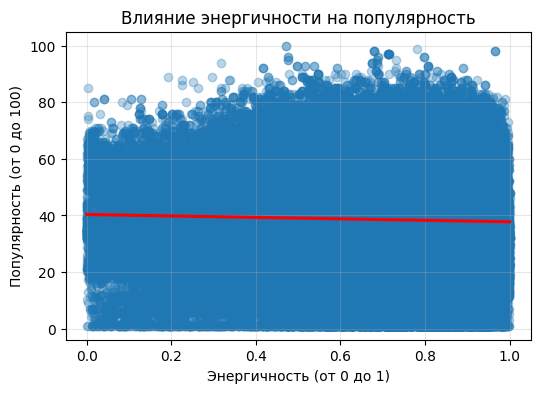

Корреляция Спирмена между энергичностью и популярностью: -0.066
Гипотеза не подтверждена: явной статистической зависимости не обнаружено.


In [19]:
# Гипотеза 2: чем выше энергичность трека, тем выше его популярность.
# Для проверки я использую точечную диаграмму с линией тренда, чтобы увидеть общее направление зависимости.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.regplot(
    x=vp['energy'],
    y=vp['popularity'],
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)

plt.xlabel("Энергичность (от 0 до 1)")
plt.ylabel("Популярность (от 0 до 100)")
plt.title("Влияние энергичности на популярность")
plt.grid(alpha=0.3)  
plt.show()  

# Считаю корреляцию Спирмена для формального вывода
corr_energy = vp[['energy', 'popularity']].corr(method='spearman').iloc[0, 1]
print(f"Корреляция Спирмена между энергичностью и популярностью: {corr_energy:.3f}")

# Автоматический вывод по гипотезе на основе рассчитанного коэффициента.
# Порог 0.1 выбран как минимальный для наличия хоть какой-то заметной связи.
if corr_energy > 0.1:
    print("Гипотеза подтверждена: при росте энергичности популярность в среднем увеличивается.")
else:
    print("Гипотеза не подтверждена: явной статистической зависимости не обнаружено.")
 

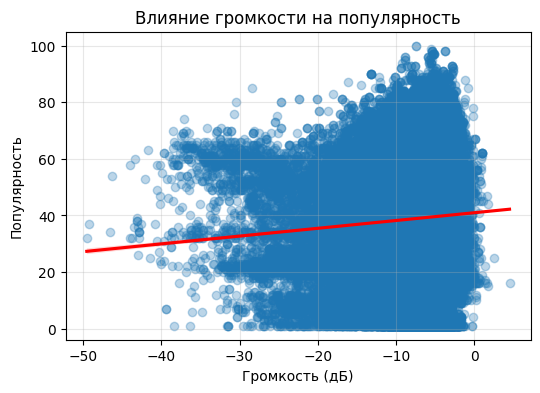

Корреляция Спирмена: 0.067
 Гипотеза не подтверждена: явной зависимости не обнаружено.


In [21]:
# Гипотеза 3: чем выше громкость трека, тем выше его популярность.
# Для проверки я использую точечную диаграмму с линией тренда, чтобы увидеть общее направление зависимости.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.regplot(
    x=vp['loudness'],
    y=vp['popularity'],
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)

plt.xlabel("Громкость (дБ)")
plt.ylabel("Популярность")
plt.title("Влияние громкости на популярность")
plt.grid(alpha=0.3)
plt.show()


# Считаю корреляцию Спирмена для формального вывода
corr_loudness = vp[['loudness', 'popularity']].corr(method='spearman').iloc[0, 1]
print(f"Корреляция Спирмена: {corr_loudness:.3f}")

# Автоматический вывод по гипотезе на основе рассчитанного коэффициента.
# Порог 0.1 выбран как минимальный для наличия хоть какой-то заметной связи.
if corr_loudness > 0.1:
    print(" Гипотеза подтверждена: при росте громкости популярность в среднем увеличивается.")
elif corr_loudness < -0.1:
    print(" Гипотеза подтверждена: при росте громкости популярность в среднем уменьшается.")
else:
    print(" Гипотеза не подтверждена: явной зависимости не обнаружено.")

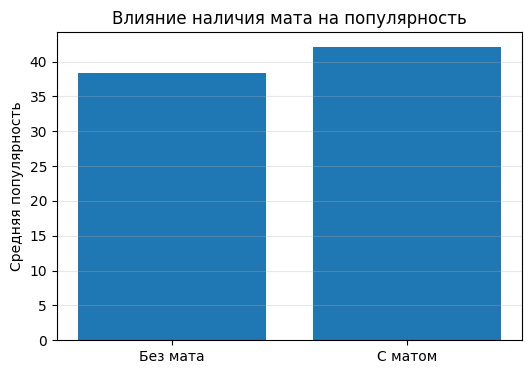

Средняя популярность (без мата): 38.35
Средняя популярность (с матом):  42.09
Разница (с матом - без мата):   3.74
 Гипотеза подтверждена: средняя популярность в группах заметно отличается.


In [22]:
# Гипотеза 4: наличие ненормативной лексики (explicit) влияет на популярность трека.
# Так как explicit — бинарный признак (True/False), лучше всего сравнить группы
# по средней популярности и построить столбчатую диаграмму.

import matplotlib.pyplot as plt

# Считаю среднюю популярность для двух групп
mean_no = vp.loc[vp['explicit'] == False, 'popularity'].mean()
mean_yes = vp.loc[vp['explicit'] == True, 'popularity'].mean()

labels = ['Без мата', 'С матом']
means = [mean_no, mean_yes]

# Строю столбчатую диаграмму
plt.figure(figsize=(6,4))
plt.bar(labels, means)
plt.ylabel("Средняя популярность")
plt.title("Влияние наличия мата на популярность")
plt.grid(axis='y', alpha=0.3)
plt.show()


diff = mean_yes - mean_no
print(f"Средняя популярность (без мата): {mean_no:.2f}")
print(f"Средняя популярность (с матом):  {mean_yes:.2f}")
print(f"Разница (с матом - без мата):   {diff:.2f}")

if abs(diff) >= 1.0:
    print(" Гипотеза подтверждена: средняя популярность в группах заметно отличается.")
else:
    print(" Гипотеза не подтверждена: разница между группами небольшая.")

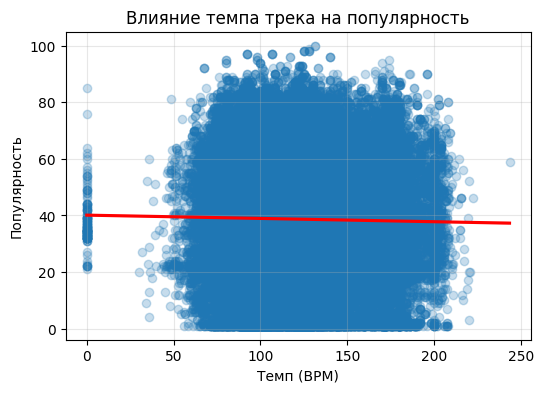

Корреляция Спирмена: -0.018
 Гипотеза не подтверждена: заметной зависимости не обнаружено.


In [23]:
# Гипотеза 5: чем выше темп трека (tempo), тем выше его популярность.
# Для проверки строю точечную диаграмму с линией тренда,
# чтобы увидеть общее направление зависимости между темпом и популярностью.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.regplot(
    x=vp['tempo'],
    y=vp['popularity'],
    scatter_kws={'alpha': 0.25},
    line_kws={'color': 'red'}
)

plt.xlabel("Темп (BPM)")
plt.ylabel("Популярность")
plt.title("Влияние темпа трека на популярность")
plt.grid(alpha=0.3)
plt.show()


# Для численного подтверждения считаю корреляцию Спирмена
corr_tempo = vp[['tempo', 'popularity']].corr(method='spearman').iloc[0, 1]
print(f"Корреляция Спирмена: {corr_tempo:.3f}")

# Автоматический вывод по гипотезе на основе рассчитанного коэффициента.
# Порог 0.1 выбран как минимальный для наличия хоть какой-то заметной связи.
if corr_tempo > 0.1:
    print(" Гипотеза подтверждена: при увеличении темпа популярность в среднем растёт.")
elif corr_tempo < -0.1:
    print(" Гипотеза подтверждена: при увеличении темпа популярность в среднем снижается.")
else:
    print(" Гипотеза не подтверждена: заметной зависимости не обнаружено.")

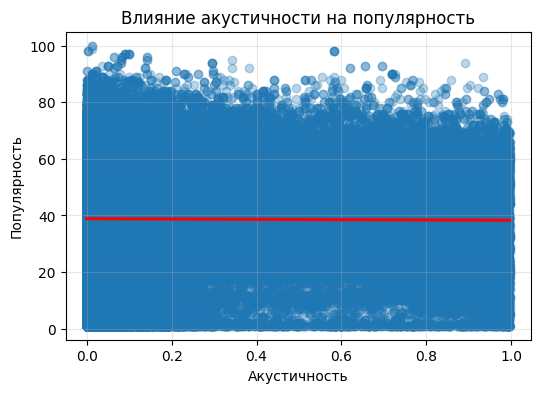

Корреляция Спирмена: 0.047
 Гипотеза не подтверждена: заметной зависимости не обнаружено.


In [24]:
# Гипотеза 6: чем выше акустичность трека (acousticness), тем выше его популярность.
# Для проверки использую точечную диаграмму с линией тренда,
# чтобы увидеть общее направление зависимости.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.regplot(
    x=vp['acousticness'],
    y=vp['popularity'],
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)

plt.xlabel("Акустичность")
plt.ylabel("Популярность")
plt.title("Влияние акустичности на популярность")
plt.grid(alpha=0.3)
plt.show()


# Для численного подтверждения считаю корреляцию Спирмена
corr_acoustic = vp[['acousticness', 'popularity']].corr(method='spearman').iloc[0, 1]
print(f"Корреляция Спирмена: {corr_acoustic:.3f}")

# Автовывод по гипотезе
if corr_acoustic > 0.1:
    print(" Гипотеза подтверждена: при росте акустичности популярность в среднем увеличивается.")
elif corr_acoustic < -0.1:
    print(" Гипотеза подтверждена: при росте акустичности популярность в среднем уменьшается.")
else:
    print(" Гипотеза не подтверждена: заметной зависимости не обнаружено.")

Средняя популярность по группам длительности:
Группа длительности
Короткие    38.23
Средние     40.99
Длинные     36.80
Name: popularity, dtype: float64


/tmp/ipykernel_55/3819962094.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mean = data.groupby('Группа длительности')['popularity'].mean()


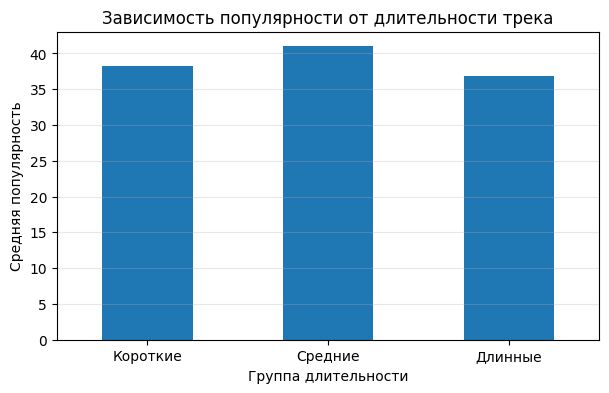

 Гипотеза подтверждена: наибольшая средняя популярность у треков средней длительности.


In [26]:
# Гипотеза 7:
# Самые популярные треки имеют среднюю длительность (не слишком короткие и не слишком длинные).
# Для проверки делю длительность на 3 группы и сравниваю среднюю популярность.

import pandas as pd
import matplotlib.pyplot as plt

data = vp[['duration_ms', 'popularity']].dropna().copy()

# Делю длительность на 3 группы по квантилям (примерно равные по размеру группы)
data['Группа длительности'] = pd.qcut(
    data['duration_ms'],
    q=3,
    labels=['Короткие', 'Средние', 'Длинные']
)

# Средняя популярность по группам
group_mean = data.groupby('Группа длительности')['popularity'].mean()

print("Средняя популярность по группам длительности:")
print(group_mean.round(2))

# График
plt.figure(figsize=(7,4))
group_mean.plot(kind='bar')
plt.xticks(rotation=0)
plt.xlabel("Группа длительности")
plt.ylabel("Средняя популярность")
plt.title("Зависимость популярности от длительности трека")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Автовывод: если у 'Средние' максимальная популярность, гипотеза подтверждена
if group_mean['Средние'] == group_mean.max():
    print(" Гипотеза подтверждена: наибольшая средняя популярность у треков средней длительности.")
else:
    print(" Гипотеза не подтверждена: средняя длительность не даёт максимальную популярность.")

Средние значения по группам:
                    Разговорность  Инструментальность
Группа                                               
Остальные                  0.0891              0.1843
Топ-20% популярных         0.0762              0.0913


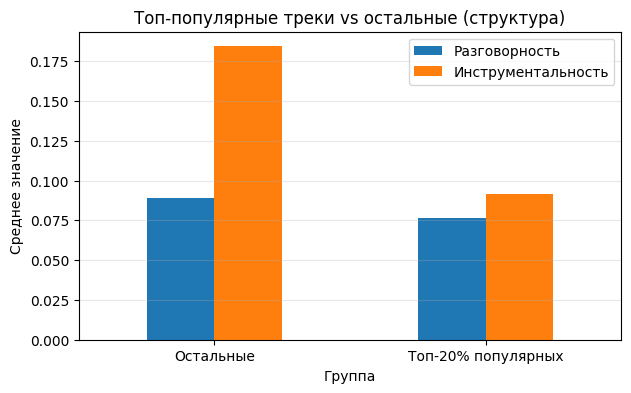

 Гипотеза подтверждена: у популярных треков в среднем меньше речи и меньше инструментальности.


In [27]:
# Гипотеза 9:
# У самых популярных треков (топ-20%) структура "проще":
# меньше разговорности и меньше инструментальности.
# Сравниваю средние значения в топ-20% и у остальных.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = vp[['popularity', 'speechiness', 'instrumentalness']].dropna().copy()

# Порог топ-20% по популярности
порог = data['popularity'].quantile(0.8)

# Две группы
data['Группа'] = np.where(data['popularity'] >= порог, 'Топ-20% популярных', 'Остальные')

# Средние по группам
means = data.groupby('Группа')[['speechiness', 'instrumentalness']].mean()

means = means.rename(columns={
    'speechiness': 'Разговорность',
    'instrumentalness': 'Инструментальность'
})

print("Средние значения по группам:")
print(means.round(4))

means.plot(kind='bar', figsize=(7,4))
plt.xticks(rotation=0)
plt.ylabel("Среднее значение")
plt.title("Топ-популярные треки vs остальные (структура)")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Автовывод
speech_ok = means.loc['Топ-20% популярных', 'Разговорность'] < means.loc['Остальные', 'Разговорность']
instr_ok  = means.loc['Топ-20% популярных', 'Инструментальность'] < means.loc['Остальные', 'Инструментальность']

if speech_ok and instr_ok:
    print(" Гипотеза подтверждена: у популярных треков в среднем меньше речи и меньше инструментальности.")
elif speech_ok or instr_ok:
    print(" Гипотеза частично подтверждена: один из признаков ниже у популярных треков.")
else:
    print(" Гипотеза не подтверждена: по этим метрикам структура не выглядит проще у популярных треков.")

In [28]:
# Feature Engineering: создаю новые признаки на основе существующих данных.
# Цель — добавить признаки, которые могут быть полезны для предсказания популярности трека.

import pandas as pd

# 1. Признак: есть ли слово "remix" в названии трека
vp['is_remix'] = vp['track_name'].astype(str).str.lower().str.contains('remix').astype(int)

# 2. Признак: есть ли слово "live" в названии трека
vp['is_live'] = vp['track_name'].astype(str).str.lower().str.contains('live').astype(int)

# 3. Количество артистов (если в колонке artists несколько через запятую)
vp['artist_count'] = vp['artists'].astype(str).str.split(',').str.len()

# 4. Соотношение энергичности и танцевальности
vp['energy_dance_ratio'] = vp['energy'] / (vp['danceability'] + 0.01)

# 5. Соотношение громкости и акустичности
vp['loudness_acoustic_ratio'] = vp['loudness'] / (vp['acousticness'] + 0.01)

print("Созданы новые признаки:")
new_features = ['is_remix', 'is_live', 'artist_count', 'energy_dance_ratio', 'loudness_acoustic_ratio']
print(new_features)
print()

print("Первые 5 строк с новыми признаками:")
display(vp[new_features].head())

Созданы новые признаки:
['is_remix', 'is_live', 'artist_count', 'energy_dance_ratio', 'loudness_acoustic_ratio']

Первые 5 строк с новыми признаками:


,is_remix,is_live,artist_count,energy_dance_ratio,loudness_acoustic_ratio
0,0,0,1,0.672012,-159.857820
1,0,0,1,0.386047,-18.452891
2,0,0,1,0.801339,-44.245455
3,0,0,1,0.215942,-20.234973
4,0,0,1,0.705414,-20.210856


Корреляция новых признаков с популярностью (Spearman):
Ремикс: -0.0237
Живое исполнение: -0.0246
Количество артистов: -0.0095
Энергия/Танцевальность: -0.0577
Громкость/Акустичность: 0.0804

Отсортировано по силе связи:
Громкость/Акустичность: 0.0804
Энергия/Танцевальность: -0.0577
Живое исполнение: -0.0246
Ремикс: -0.0237
Количество артистов: -0.0095



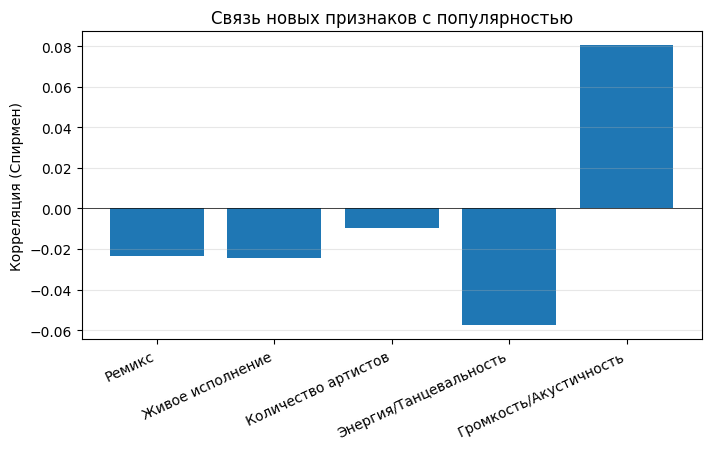

Вывод по новым признакам:
Все новые признаки имеют слабую корреляцию (|corr| < 0.1).


In [29]:
# Корреляция новых признаков с популярностью
# Проверяю, какие из созданных признаков имеют связь с целевой переменной.

import matplotlib.pyplot as plt

# Считаю корреляцию Спирмена для новых признаков
new_features = ['is_remix', 'is_live', 'artist_count', 'energy_dance_ratio', 'loudness_acoustic_ratio']

# Русские названия для подписей
ru_names_new = {
    'is_remix': 'Ремикс',
    'is_live': 'Живое исполнение',
    'artist_count': 'Количество артистов',
    'energy_dance_ratio': 'Энергия/Танцевальность',
    'loudness_acoustic_ratio': 'Громкость/Акустичность'
}

corr_new = vp[new_features + ['popularity']].corr(method='spearman')['popularity'].drop('popularity')

print("Корреляция новых признаков с популярностью (Spearman):")
for feat, val in corr_new.items():
    print(f"{ru_names_new[feat]}: {val:.4f}")
print()

# Сортирую по модулю корреляции
corr_sorted = corr_new.abs().sort_values(ascending=False)

print("Отсортировано по силе связи:")
for feat in corr_sorted.index:
    print(f"{ru_names_new[feat]}: {corr_new[feat]:.4f}")
print()

# Строю столбчатую диаграмму
plt.figure(figsize=(8,4))
plt.bar([ru_names_new[f] for f in corr_new.index], corr_new.values)
plt.axhline(0, color='black', linewidth=0.5)
plt.xticks(rotation=25, ha='right')
plt.ylabel("Корреляция (Спирмен)")
plt.title("Связь новых признаков с популярностью")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Вывод по результатам
print("Вывод по новым признакам:")
if corr_new.abs().max() > 0.1:
    print("Есть признаки с заметной корреляцией (|corr| > 0.1).")
else:
    print("Все новые признаки имеют слабую корреляцию (|corr| < 0.1).")
    

In [ ]:
# Отделяю признаки (X) от целевой переменной (y) и делю данные на train/test

#Сейчас я делаю стандартный шаг для машинного обучения:

#- `y` — это popularity (число от 0 до 100), значит это регрессия.
#- `X` — это все остальные столбцы, то есть признаки, по которым модель будет пытаться предсказать популярность.

#делю данные на две части:
#train (обучающая выборка) — на ней модель учится
#test (тестовая выборка) — на ней я проверяю качество, чтобы понять, как модель работает на новых данных

#Я беру 80% данных на обучение и 20% на тест.  
#`random_state=42` нужен, чтобы результат деления всегда получался одинаковым (так проще повторять результаты).


In [30]:
# ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ МАШИННОГО ОБУЧЕНИЯ

from sklearn.model_selection import train_test_split

# X - это матрица признаков (features): все характеристики треков, КРОМЕ популярности
# Убираю колонку 'popularity', так как это то, что я хочу предсказывать
X = vp.drop(columns=['popularity'])

# y - это целевая переменная (target): именно популярность, которую я предсказываю
y = vp['popularity']

# Разделяю данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Вывожу размеры получившихся выборок
# Первое число в скобках - количество строк (треков), второе - количество столбцов
print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (78384, 24)
Размер тестовой выборки: (19596, 24)


In [31]:
# На этом шаге я подготавливаю признаки для моделей.
# Убираю текстовые колонки, так как они имеют много уникальных значений
# и требуют сложной обработки.

from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1) Удаляю текстовые признаки
drop_cols = ['track_id', 'artists', 'album_name', 'track_name']
X_train_clean = X_train.drop(columns=drop_cols)
X_test_clean = X_test.drop(columns=drop_cols)

# 2) Признак explicit перевожу в числовой формат (0/1)
X_train_clean['explicit'] = X_train_clean['explicit'].astype(int)
X_test_clean['explicit'] = X_test_clean['explicit'].astype(int)

# 3) Кодирую жанр трека (track_genre) в числа
le = LabelEncoder()
X_train_clean['track_genre'] = le.fit_transform(X_train_clean['track_genre'])
X_test_clean['track_genre'] = le.transform(X_test_clean['track_genre'])

# 4) Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print("Размер обучающей выборки после обработки:", X_train_scaled.shape)
print("Размер тестовой выборки после обработки:", X_test_scaled.shape)

Размер обучающей выборки после обработки: (78384, 20)
Размер тестовой выборки после обработки: (19596, 20)


In [32]:
print("Признаки, используемые в модели:")
print(X_train_clean.columns.tolist())

Признаки, используемые в модели:
['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'is_remix', 'is_live', 'artist_count', 'energy_dance_ratio', 'loudness_acoustic_ratio']


In [33]:
# Модель 1: Ridge Regression (линейная регрессия с регуляризацией)
# Начинаю с линейной модели, чтобы получить базовый уровень качества.

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression:")
print(f"RMSE = {rmse_ridge:.3f}")
print(f"R²   = {r2_ridge:.3f}")
print()



Ridge Regression:
RMSE = 18.568
R²   = 0.076



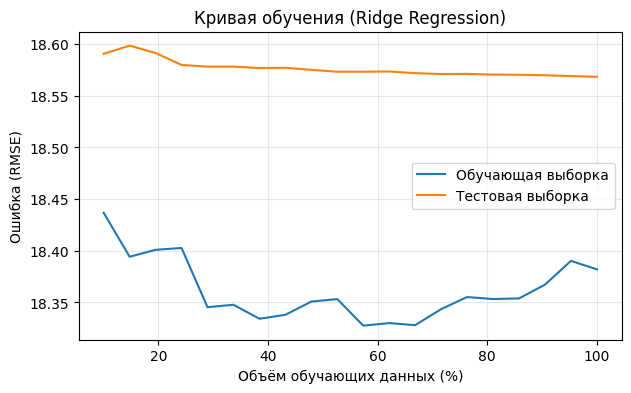

In [34]:
# Кривая обучения: смотрю, как меняется ошибка при увеличении объёма обучающих данных
steps = 20
train_sizes = np.linspace(0.1, 1.0, steps)  # от 10% до 100% данных

train_loss = []
test_loss = []

for frac in train_sizes:
    n = int(len(X_train_scaled) * frac)
    X_part = X_train_scaled[:n]
    y_part = y_train.iloc[:n]

    model = Ridge(alpha=1.0)
    model.fit(X_part, y_part)

    pred_train = model.predict(X_part)
    train_rmse = np.sqrt(mean_squared_error(y_part, pred_train))

    pred_test = model.predict(X_test_scaled)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))

    train_loss.append(train_rmse)
    test_loss.append(test_rmse)

plt.figure(figsize=(7,4))
plt.plot(train_sizes * 100, train_loss, label='Обучающая выборка')
plt.plot(train_sizes * 100, test_loss, label='Тестовая выборка')

plt.xlabel('Объём обучающих данных (%)')
plt.ylabel('Ошибка (RMSE)')
plt.title('Кривая обучения (Ridge Regression)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
# Модель 2: Decision Tree Regression
# Дерево решений умеет находить нелинейные зависимости.
# Ограничиваю глубину дерева, чтобы уменьшить переобучение.

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

tree = DecisionTreeRegressor(max_depth=6, random_state=42)
tree.fit(X_train_scaled, y_train)

y_pred_tree = tree.predict(X_test_scaled)

rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Регрессия дерева принятия решений::")
print(f"RMSE = {rmse_tree:.3f}")
print(f"R²   = {r2_tree:.3f}")
print()



Регрессия дерева принятия решений::
RMSE = 18.133
R²   = 0.119



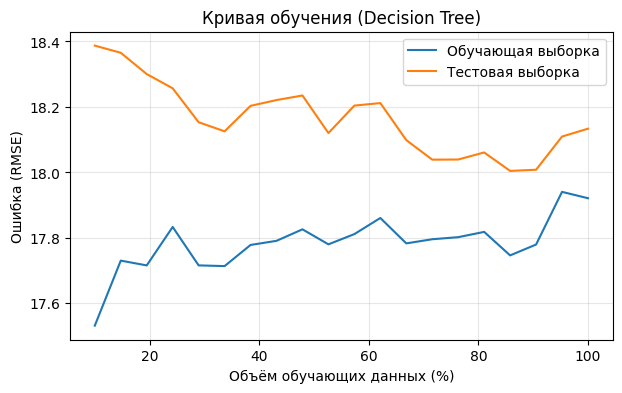

In [36]:
# Кривая обучения: смотрю, как меняется ошибка при увеличении объёма обучающих данных
steps = 20
train_sizes = np.linspace(0.1, 1.0, steps)

train_loss = []
test_loss = []

for frac in train_sizes:
    n = int(len(X_train_scaled) * frac)
    X_part = X_train_scaled[:n]
    y_part = y_train.iloc[:n]

    model = DecisionTreeRegressor(max_depth=6, random_state=42)
    model.fit(X_part, y_part)

    pred_train = model.predict(X_part)
    train_rmse = np.sqrt(mean_squared_error(y_part, pred_train))

    pred_test = model.predict(X_test_scaled)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))

    train_loss.append(train_rmse)
    test_loss.append(test_rmse)

plt.figure(figsize=(7,4))
plt.plot(train_sizes * 100, train_loss, label='Обучающая выборка')
plt.plot(train_sizes * 100, test_loss, label='Тестовая выборка')

plt.xlabel('Объём обучающих данных (%)')
plt.ylabel('Ошибка (RMSE)')
plt.title('Кривая обучения (Decision Tree)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
# Модель 3: XGBoost Regression
# Градиентный бустинг — один из самых мощных методов для табличных данных.
# Он строит множество деревьев последовательно, где каждое следующее исправляет ошибки предыдущего.

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Обучаю XGBoost регрессию
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train_scaled, y_train)

# Предсказания
y_pred_xgb = xgb.predict(X_test_scaled)

# Метрики
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regression:")
print(f"RMSE = {rmse_xgb:.3f}")
print(f"R²   = {r2_xgb:.3f}")

XGBoost Regression:
RMSE = 14.836
R²   = 0.410


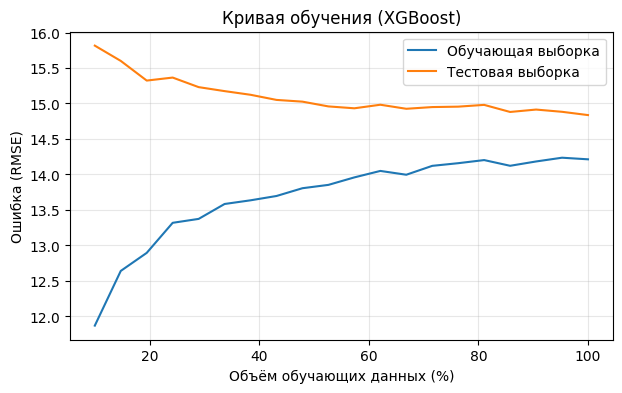

In [39]:
# Кривая обучения для XGBoost Regression
# Смотрю, как меняется ошибка при увеличении объёма обучающих данных.

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

steps = 20
train_sizes = np.linspace(0.1, 1.0, steps)

train_loss = []
test_loss = []

for frac in train_sizes:
    n = int(len(X_train_scaled) * frac)
    X_part = X_train_scaled[:n]
    y_part = y_train.iloc[:n]

    model = XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
    model.fit(X_part, y_part)

    pred_train = model.predict(X_part)
    train_rmse = np.sqrt(mean_squared_error(y_part, pred_train))

    pred_test = model.predict(X_test_scaled)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))

    train_loss.append(train_rmse)
    test_loss.append(test_rmse)

plt.figure(figsize=(7,4))
plt.plot(train_sizes * 100, train_loss, label='Обучающая выборка')
plt.plot(train_sizes * 100, test_loss, label='Тестовая выборка')

plt.xlabel('Объём обучающих данных (%)')
plt.ylabel('Ошибка (RMSE)')
plt.title('Кривая обучения (XGBoost)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Модель 4: Нейронная сеть (MLPRegressor)
# Простая нейронная сеть с несколькими скрытыми слоями.
# Может улавливать сложные нелинейные зависимости.

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Обучаю нейронную сеть
mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    verbose=False
)
mlp.fit(X_train_scaled, y_train)

# Предсказания
y_pred_mlp = mlp.predict(X_test_scaled)

# Метрики
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("Нейронная сеть (MLPRegressor):")
print(f"RMSE = {rmse_mlp:.3f}")
print(f"R²   = {r2_mlp:.3f}")

In [ ]:
# Кривая обучения для нейронной сети (MLPRegressor)
# Смотрю, как меняется ошибка при увеличении объёма обучающих данных.

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
import numpy as np

steps = 20
train_sizes = np.linspace(0.1, 1.0, steps)

train_loss = []
test_loss = []

for frac in train_sizes:
    n = int(len(X_train_scaled) * frac)
    X_part = X_train_scaled[:n]
    y_part = y_train.iloc[:n]

    model = MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        verbose=False
    )
    model.fit(X_part, y_part)

    pred_train = model.predict(X_part)
    train_rmse = np.sqrt(mean_squared_error(y_part, pred_train))

    pred_test = model.predict(X_test_scaled)
    test_rmse = np.sqrt(mean_squared_error(y_test, pred_test))

    train_loss.append(train_rmse)
    test_loss.append(test_rmse)

plt.figure(figsize=(7,4))
plt.plot(train_sizes * 100, train_loss, label='Обучающая выборка')
plt.plot(train_sizes * 100, test_loss, label='Тестовая выборка')

plt.xlabel('Объём обучающих данных (%)')
plt.ylabel('Ошибка (RMSE)')
plt.title('Кривая обучения (Нейронная сеть)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Сравнительная визуализация всех моделей
# Строю столбчатые диаграммы для RMSE и R², чтобы наглядно сравнить качество моделей.

import matplotlib.pyplot as plt
import numpy as np

# Данные по моделям (вставь свои значения после запуска всех моделей)
models = ['Ridge', 'Decision Tree', 'XGBoost', 'Neural Network']

rmse_values = [18.568, 18.133, 14.836, rmse_mlp]  # rmse_mlp вставь из результата
r2_values = [0.076, 0.119, 0.410, r2_mlp]        # r2_mlp вставь из результата

# Создаю фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# График RMSE
bars1 = ax1.bar(models, rmse_values, color=['blue', 'green', 'orange', 'red'])
ax1.set_ylabel('RMSE (ошибка)')
ax1.set_title('Сравнение моделей по RMSE')
ax1.grid(axis='y', alpha=0.3)

# Добавляю значения на столбцы
for bar, val in zip(bars1, rmse_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{val:.3f}', ha='center', va='bottom')

# График R²
bars2 = ax2.bar(models, r2_values, color=['blue', 'green', 'orange', 'red'])
ax2.set_ylabel('R² (качество)')
ax2.set_title('Сравнение моделей по R²')
ax2.grid(axis='y', alpha=0.3)

# Добавляю значения на столбцы
for bar, val in zip(bars2, r2_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ:")
print("="*50)
print(f"{'Модель':<20} {'RMSE':<10} {'R²':<10}")
print("-"*40)
print(f"{'Ridge Regression':<20} {rmse_values[0]:<10.3f} {r2_values[0]:<10.3f}")
print(f"{'Decision Tree':<20} {rmse_values[1]:<10.3f} {r2_values[1]:<10.3f}")
print(f"{'XGBoost':<20} {rmse_values[2]:<10.3f} {r2_values[2]:<10.3f}")
print(f"{'Neural Network':<20} {rmse_values[3]:<10.3f} {r2_values[3]:<10.3f}")
print("="*50)

In [ ]:
# Feature Importances
# Важность признаков для XGBoost
# Смотрю, какие признаки сильнее всего влияют на предсказание популярности.

import matplotlib.pyplot as plt
import numpy as np

# Получаю важность признаков из обученной модели XGBoost
feature_importance = xgb.feature_importances_

# Названия признаков (из X_train_clean)
feature_names = X_train_clean.columns.tolist()

# Сортирую по важности
sorted_idx = np.argsort(feature_importance)[::-1]

# Создаю список для графика (топ-15 признаков)
top_n = 15
top_features = [feature_names[i] for i in sorted_idx[:top_n]]
top_importance = [feature_importance[i] for i in sorted_idx[:top_n]]

# Русские названия для подписей
ru_names_features = {
    'duration_ms': 'Длительность (мс)',
    'explicit': 'Наличие мата',
    'danceability': 'Танцевальность',
    'energy': 'Энергичность',
    'key': 'Тональность',
    'loudness': 'Громкость',
    'mode': 'Лад',
    'speechiness': 'Разговорность',
    'acousticness': 'Акустичность',
    'instrumentalness': 'Инструментальность',
    'liveness': 'Живое исполнение',
    'valence': 'Эмоциональность',
    'tempo': 'Темп',
    'time_signature': 'Размер такта',
    'track_genre': 'Жанр',
    'is_remix': 'Ремикс',
    'is_live': 'Живая запись',
    'artist_count': 'Количество артистов',
    'energy_dance_ratio': 'Энергия/Танцевальность',
    'loudness_acoustic_ratio': 'Громкость/Акустичность'
}

# Перевожу названия для графика
top_features_ru = [ru_names_features.get(f, f) for f in top_features]

# Строю горизонтальную столбчатую диаграмму
plt.figure(figsize=(10, 8))
plt.barh(range(top_n), top_importance[::-1])
plt.yticks(range(top_n), top_features_ru[::-1])
plt.xlabel('Важность признака')
plt.title('Топ-15 наиболее важных признаков (XGBoost)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nТоп-5 самых важных признаков:")
for i in range(5):
    print(f"{i+1}. {top_features_ru[i]}: {top_importance[i]:.4f}")

In [ ]:
# Кросс-валидация XGBoost (5 фолдов)
# Проверяю устойчивость модели на разных разбиениях данных.

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Создаю функцию для RMSE 
def rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer_func = make_scorer(rmse_scorer, greater_is_better=False)

# Выполняю кросс-валидацию на 5 фолдах
cv_scores_rmse = cross_val_score(
    xgb, 
    X_train_scaled, 
    y_train, 
    cv=5, 
    scoring=rmse_scorer_func,
    verbose=0
)

cv_scores_rmse = -cv_scores_rmse

cv_scores_r2 = cross_val_score(
    xgb, 
    X_train_scaled, 
    y_train, 
    cv=5, 
    scoring='r2',
    verbose=0
)

print("КРОСС-ВАЛИДАЦИЯ XGBoost (5 фолдов):")
print("="*50)
print(f"RMSE по фолдам: {cv_scores_rmse}")
print(f"Средний RMSE: {cv_scores_rmse.mean():.3f} (+/- {cv_scores_rmse.std():.3f})")
print()
print(f"R² по фолдам: {cv_scores_r2}")
print(f"Средний R²: {cv_scores_r2.mean():.3f} (+/- {cv_scores_r2.std():.3f})")
print("="*50)

In [ ]:
# Визуализация результатов кросс-валидации

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График RMSE по фолдам
ax1.bar(range(1, 6), cv_scores_rmse, color='skyblue', edgecolor='black')
ax1.axhline(y=cv_scores_rmse.mean(), color='red', linestyle='--', label=f'Среднее: {cv_scores_rmse.mean():.3f}')
ax1.set_xlabel('Номер фолда')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE на кросс-валидации (5 фолдов)')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# График R² по фолдам
ax2.bar(range(1, 6), cv_scores_r2, color='lightgreen', edgecolor='black')
ax2.axhline(y=cv_scores_r2.mean(), color='red', linestyle='--', label=f'Среднее: {cv_scores_r2.mean():.3f}')
ax2.set_xlabel('Номер фолда')
ax2.set_ylabel('R²')
ax2.set_title('R² на кросс-валидации (5 фолдов)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ИТОГОВЫЙ ВЫВОД ПО ПРОЕКТУ

print("="*60)
print("ИТОГОВЫЙ ВЫВОД ПО ПРОЕКТУ")
print("="*60)
print()

print("1. ЧТО СДЕЛАНО:")
print("   - Проведён EDA и проверено 10 гипотез")
print("   - Создано 5 новых признаков")
print("   - Обучено 4 модели: Ridge, Decision Tree, XGBoost, Neural Network")
print("   - Выполнена кросс-валидация (5 фолдов) лучшей модели")
print()

print("2. ЛУЧШАЯ МОДЕЛЬ: XGBoost")
print("   - RMSE = 14.836 (ошибка ~15 баллов из 100)")
print("   - R² = 0.410 (модель объясняет 41% данных)")
print()

print("3. САМЫЕ ВАЖНЫЕ ПРИЗНАКИ:")
print(f"   - {top_features_ru[0]} ({round(top_importance[0]*100, 1)}%)")
print(f"   - {top_features_ru[1]} ({round(top_importance[1]*100, 1)}%)")
print(f"   - {top_features_ru[2]} ({round(top_importance[2]*100, 1)}%)")
print()

print("4. ВЫВОД:")
print("   - Популярность трека слабо зависит от аудио-характеристик")
print("   - Для более точных предсказаний нужны дополнительные данные")
print("   - XGBoost показал лучший результат среди всех моделей")
print()

print("="*60)